# ETS MARL — Episode Viewer

Inspect **one** episode at the finest grain available. Use this notebook to:

- Load a configuration (and optionally a trained checkpoint, e.g. the final episode of a long run).
- Roll out a single deterministic episode and capture every per-year log + per-company snapshot.
- Switch between a **market perspective** (cap / TNAC / MSR / clearing prices / volumes / defaults) and a **company perspective** (budgets, transactions, investments, compliance, rewards).
- Drill into a single year (`INSPECT_YEAR`) or a single company across the whole episode (`INSPECT_AGENT`).

Everything below is plain pandas / matplotlib; nothing is hidden in helper modules. Tweak the controls in the next cell, run all, and use the section headers as a table of contents.


In [1]:
# Install notebook dependencies if needed.
# Set INSTALL_NOTEBOOK_DEPS = True (or run the cell with required packages missing)
# to pip-install everything in notebooks/requirements-notebooks.txt using the
# CURRENT kernel's interpreter. This is more reliable than `%pip install -r {path}`
# (IPython magics don't expand `{var}` at runtime) and works on Azure / Colab / local.
import subprocess, sys, importlib, re
from pathlib import Path

INSTALL_NOTEBOOK_DEPS = False  # flip to True to force-reinstall

# Map PyPI distribution name -> import module name when they differ.
_DIST_TO_IMPORT = {
    "pyyaml": "yaml",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "opencv-python": "cv2",
    "pillow": "PIL",
    "beautifulsoup4": "bs4",
    "ipython": "IPython",
}

def _find_requirements():
    req_name = "requirements-notebooks.txt"
    here = Path.cwd()
    candidates = [here / req_name, here / "notebooks" / req_name]
    candidates.extend(p / "notebooks" / req_name for p in here.parents)
    return next((p for p in candidates if p.exists()), None)

def _parse_requirements(req_path):
    """Extract distribution names from a requirements file (skip comments, options, env markers)."""
    dists = []
    for raw in req_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or line.startswith("-"):
            continue
        # Strip env markers and extras: "pkg[extra]>=1.0; python_version>='3.9'"
        line = line.split(";", 1)[0].strip()
        m = re.match(r"^([A-Za-z0-9_.\-]+)", line)
        if m:
            dists.append(m.group(1).lower())
    return dists

def _missing_required(dists):
    missing = []
    for dist in dists:
        mod = _DIST_TO_IMPORT.get(dist, dist.replace("-", "_"))
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(dist)
    return missing

req_path = _find_requirements()
if req_path is None:
    raise FileNotFoundError("Could not find notebooks/requirements-notebooks.txt")

dists = _parse_requirements(req_path)
missing = _missing_required(dists)

if INSTALL_NOTEBOOK_DEPS or missing:
    if missing:
        print(f"Missing packages: {missing}")
    print(f"Installing notebook dependencies from: {req_path}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
else:
    print(f"All {len(dists)} notebook dependencies present; skipping install.")
    print("(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)")


All 14 notebook dependencies present; skipping install.
(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)


## 1. Controls

Set the inputs for the rollout. The notebook is fully self-contained — no external `debug_*` script required.

- `CONFIG_PATH` — YAML config to use. Defaults to `configs/default.yaml`.
- `SEED` — RNG seed for reset() + policies.
- `CHECKPOINT_DIR` — directory containing `agent_<i>_best.pt` (or any of the `agent_<i>_*.pt` checkpoints saved by `train.py`). Set to `None` to fall back to untrained agents (random initialisation).
- `CHECKPOINT_PATTERN` — filename pattern to look for inside `CHECKPOINT_DIR` (e.g. `agent_{i}_best.pt`, `agent_{i}_final.pt`).
- `N_BOTS_OVERRIDE` / `N_LEARNING_OVERRIDE` — set to `None` to use what's in the config, or override (e.g. `N_BOTS_OVERRIDE=0` to remove bots from the view).
- `DETERMINISTIC` — if `True`, policies act on the mean (no exploration noise).
- `INSPECT_YEAR` — 1-based year to deep-dive (set to `None` to deep-dive the last simulated year).
- `INSPECT_AGENT` — agent index for the single-company walk-through.
- `EXPORT_DIR` — where to write the optional CSV exports (created if missing).


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

# --- locate project root --------------------------------------------------
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "configs").exists() and (parent / "src").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- USER CONTROLS --------------------------------------------------------
CONFIG_PATH         = PROJECT_ROOT / "configs" / "default.yaml"
SEED                = 1729

# Set to a checkpoint directory (e.g. results/checkpoints_default_s42/) to load
# a trained policy and inspect "the final episode of a long run". Leave None to
# use freshly initialised PPO networks (useful for sanity-checking the env only).
CHECKPOINT_DIR      = PROJECT_ROOT / "results" / "sweeps" / "default" / "checkpoints_default_s1729.tar.xz"
CHECKPOINT_PATTERN  = "agent_{i}_best.pt"  # try "agent_{i}_final.pt" if _best is missing

# Override participant counts (None = use config values).
N_LEARNING_OVERRIDE = None
N_BOTS_OVERRIDE     = None

DETERMINISTIC       = True

# Year/agent of interest. INSPECT_YEAR is 1-based; None = last simulated year.
INSPECT_YEAR        = None
INSPECT_AGENT       = 0

# Export controls.
EXPORT_CSV          = False
EXPORT_DIR          = PROJECT_ROOT / "results" / "episode_viewer"

# Display controls (how wide to print pandas tables).
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")


## 2. Load config & build environment

Loads the YAML, applies optional overrides, builds an `ETSEnvironment`, and (if `CHECKPOINT_DIR` is set) loads PPO actors via the same `build_agents` factory used by `scripts/train.py` and `scripts/evaluate.py`.


In [3]:
from src.environment.ets_environment import ETSEnvironment
from scripts.train import build_agents

with open(CONFIG_PATH) as fh:
    cfg = yaml.safe_load(fh)

# Apply optional overrides BEFORE constructing the environment so all
# downstream sizing (obs/action dims, bot arrays, etc.) is consistent.
if N_LEARNING_OVERRIDE is not None:
    cfg["companies"]["n_agents"] = int(N_LEARNING_OVERRIDE)
if N_BOTS_OVERRIDE is not None:
    cfg["companies"]["n_bot_agents"] = int(N_BOTS_OVERRIDE)

env = ETSEnvironment(cfg, seed=SEED)
N_LEARNING = int(cfg["companies"]["n_agents"])
N_BOTS     = int(cfg["companies"]["n_bot_agents"])
N_TOTAL    = env.n_total
N_YEARS    = int(cfg["simulation"]["n_years"])
TECH_NAMES = list(cfg["technologies"]["names"])
BUILDABLE_TECH_NAMES = [TECH_NAMES[i] for i, b in enumerate(cfg["technologies"]["is_buildable"]) if b]

# Build PPO agents using the same factory as scripts/train.py and scripts/evaluate.py.
# When CHECKPOINT_DIR is supplied we load the trained weights; otherwise the agents
# stay at their random initialisation, which gives a clean "untrained baseline" view
# of the environment. Bots, when present, are driven by the env's own heuristic
# policy inside step_auction / step_secondary, so this notebook only needs to
# produce actions for the LEARNING agents.
agents = build_agents(env, cfg, SEED)
policy_mode = "untrained_ppo"
missing = []
if CHECKPOINT_DIR is not None:
    ckpt_root = Path(CHECKPOINT_DIR)
    if not ckpt_root.is_absolute():
        ckpt_root = PROJECT_ROOT / ckpt_root
    if not ckpt_root.exists():
        raise FileNotFoundError(f"CHECKPOINT_DIR not found: {ckpt_root}")
    for i, ag in enumerate(agents):
        ckpt_path = ckpt_root / CHECKPOINT_PATTERN.format(i=i)
        if ckpt_path.exists():
            ag.load(str(ckpt_path))
        else:
            missing.append(i)
    if missing:
        print(f"WARNING: missing checkpoints for agents {missing} — they keep random init.")
    policy_mode = f"checkpoint:{ckpt_root.name}"

print(f"Project root        : {PROJECT_ROOT}")
print(f"Config              : {CONFIG_PATH}")
print(f"Years simulated     : {N_YEARS}")
print(f"Learning agents     : {N_LEARNING}    Bots: {N_BOTS}    Total: {N_TOTAL}")
print(f"Policy mode         : {policy_mode}")
print(f"Deterministic actions: {DETERMINISTIC}")


Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
Project root        : c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction
Config              : c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\configs\default.yaml
Years simulated     : 12
Learning agents     : 8    Bots: 0    Total: 8
Policy mode         : checkpoint:checkpoints_default_s1729.tar.xz
Deterministic actions: True


## 3. Roll out one episode and capture everything

Helper functions:

- `participant_label(i)` — `A0..A{N_LEARNING-1}` for learners, `B0..B{N_BOTS-1}` for bots.
- `select_phase1/2_actions(obs)` — drives the **learning** agents using the actors built above (trained when a checkpoint was loaded; random init otherwise). Bot actions are produced inside the environment\'s `step_*` methods.

Each year we record:

1. The **pre-step snapshot** (annual budget, budget already spent, treasury, loan, bank, mix, queue size).
2. The **raw actions** (auction 6-D, secondary 2-D) — what the policy actually emitted, before any environment-side clipping/gating.
3. The full **`year_log`** dict returned by `step_secondary` (this is the same dict used by `train.py` for diagnostics).
4. The **post-step snapshot** of the same per-company state.


In [4]:
from tqdm.auto import tqdm


def participant_label(i: int) -> str:
    return f"A{i}" if i < N_LEARNING else f"B{i - N_LEARNING}"

def participant_kind(i: int) -> str:
    return "learning" if i < N_LEARNING else "bot"

def select_phase1_actions(obs1):
    actions = np.zeros((N_LEARNING, 6), dtype=np.float32)
    for i in range(N_LEARNING):
        a, _, _ = agents[i].select_auction_action(obs1[i], deterministic=DETERMINISTIC)
        actions[i] = a
    return actions

def select_phase2_actions(obs2):
    actions = np.zeros((N_LEARNING, 2), dtype=np.float32)
    for i in range(N_LEARNING):
        a, _, _ = agents[i].select_secondary_action(obs2[i], deterministic=DETERMINISTIC)
        actions[i] = a
    return actions

def snapshot_companies():
    rows = []
    for i, c in enumerate(env.companies):
        rows.append({
            "agent": i,
            "label": participant_label(i),
            "kind": participant_kind(i),
            "annual_budget": float(c.annual_budget),
            "budget_spent": float(c.budget_spent_this_year),
            "budget_avail": float(c.annual_budget - c.budget_spent_this_year),
            "treasury": float(c._treasury_reserve),
            "treasury_drawn": float(c._treasury_drawn_this_year),
            "loan_outstanding": float(c._loan_outstanding),
            "bank_holdings": float(env.holdings[i]),
            "carry_forward": float(c._carry_forward),
            "green_frac": float(c.green_frac),
            "fossil_frac": float(c.fossil_frac),
            "queue_size": int(len(c._construction_queue)),
            **{f"mix_{TECH_NAMES[t]}": float(c.mix[t]) for t in range(len(TECH_NAMES))},
        })
    return pd.DataFrame(rows)

# ---- Reset & roll out -----------------------------------------------------
obs1, _ = env.reset(seed=SEED)
year_logs        = []   # one dict per simulated year
pre_snapshots    = []   # company snapshots BEFORE step_auction
post_snapshots   = []   # company snapshots AFTER step_secondary
raw_phase1_acts  = []   # raw learning-agent phase-1 actions
raw_phase2_acts  = []   # raw learning-agent phase-2 actions
total_rewards    = np.zeros(N_LEARNING)

for year in tqdm(range(N_YEARS), desc='Rolling out episode', unit='year', leave=True):
    pre_snapshots.append(snapshot_companies().assign(year=year + 1))

    a1 = select_phase1_actions(obs1)
    raw_phase1_acts.append(a1.copy())
    obs2, _ = env.step_auction(a1)

    a2 = select_phase2_actions(obs2)
    raw_phase2_acts.append(a2.copy())
    obs1, rewards, terminated, _, info = env.step_secondary(a2)
    total_rewards += rewards

    log = info["year_log"]
    log["_year_1based"] = year + 1
    year_logs.append(log)
    post_snapshots.append(snapshot_companies().assign(year=year + 1))

    if terminated:
        break

YEARS_DONE = len(year_logs)
print(f"Simulated {YEARS_DONE}/{N_YEARS} years.")
print("Total learning-agent rewards (raw):")
display(pd.DataFrame({
    "agent": [participant_label(i) for i in range(N_LEARNING)],
    "total_reward": total_rewards,
}))

# Resolve INSPECT_YEAR / INSPECT_AGENT now that we know YEARS_DONE.
if INSPECT_YEAR is None:
    INSPECT_YEAR = YEARS_DONE
if not (1 <= INSPECT_YEAR <= YEARS_DONE):
    raise ValueError(f"INSPECT_YEAR must be in [1, {YEARS_DONE}], got {INSPECT_YEAR}.")
if not (0 <= INSPECT_AGENT < N_TOTAL):
    raise ValueError(f"INSPECT_AGENT must be in [0, {N_TOTAL - 1}], got {INSPECT_AGENT}.")
print(f"Year deep-dive: INSPECT_YEAR={INSPECT_YEAR}    Single-company walk-through: INSPECT_AGENT={INSPECT_AGENT} ({participant_label(INSPECT_AGENT)})")


[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.90, A2=1.57, A3=1.66, A4=1.57, A5=1.00, A6=1.22, A7=0.80, A8=0.87
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.


Rolling out episode:   0%|          | 0/12 [00:00<?, ?year/s]

Simulated 12/12 years.
Total learning-agent rewards (raw):


,agent,total_reward
0,A0,0.3918
1,A1,-14.5759
2,A2,1.9205
3,A3,5.8101
4,A4,-19.8519
5,A5,3.2946
6,A6,1.1387
7,A7,7.2103


Year deep-dive: INSPECT_YEAR=12    Single-company walk-through: INSPECT_AGENT=0 (A0)


## 4. Episode summary — Market perspective

One row per simulated year. Use this to spot regime shifts (price hitting reserve, MSR firing, defaults, etc.) at a glance, before drilling into a specific year.


In [5]:
def _g(d, key, default=np.nan):
    v = d.get(key, default)
    return v if v is not None else default

market_rows = []
for log in year_logs:
    stats = log.get("auction_stats", {}) or {}
    market_rows.append({
        "year"                 : log["_year_1based"],
        "cap_mt"               : float(_g(log, "cap")),
        "tnac_mt"              : float(_g(log, "tnac")),
        "msr_reserve_mt"       : float(_g(log, "msr_reserve", 0.0)),
        "msr_withhold_mt"      : float(_g(log, "msr_withhold_this_year", 0.0)),
        "msr_release_mt"       : float(_g(log, "msr_release_this_year", 0.0)),
        "msr_total_cancelled"  : float(_g(log, "msr_total_cancelled", 0.0)),
        "auction_volume_mt"    : float(_g(log, "auction_volume")),
        "rollover_in_mt"       : float(_g(log, "unsold_rollover_in", 0.0)),
        "rollover_out_mt"      : float(_g(log, "unsold_rollover_out", 0.0)),
        "default_rolled_in_mt" : float(_g(log, "defaulted_volume_rolled_in", 0.0)),
        "reserve_eur"          : float(_g(log, "effective_reserve")),
        "anchor_eur"           : float(_g(log, "anchor_t")) if log.get("anchor_t") is not None else np.nan,
        "auction_clearing_eur" : float(_g(log, "clearing_price")),
        "secondary_clearing_eur": float(_g(log, "secondary_clearing")),
        "auction_demand_mt"    : float(stats.get("total_demand", np.nan)),
        "auction_allocated_mt" : float(stats.get("total_allocated", np.nan)),
        "auction_failed"       : bool(stats.get("auction_failed", False)),
        "auction_defaults"     : int(stats.get("defaults", 0)),
        "secondary_volume_mt"  : float(_g(log, "secondary_volume", 0.0)),
        "phantom_active"       : bool(_g(log, "phantom_active", False)),
        "phantom_bid_eur"      : float(_g(log, "phantom_bid_price", np.nan)),
        "phantom_bid_qty_mt"   : float(_g(log, "phantom_bid_qty", np.nan)),
        "emissions_total_mt"   : float(np.sum(_g(log, "emissions", []))),
        "shortfalls_total_mt"  : float(np.sum(_g(log, "shortfalls", []))),
        "penalties_total_meur" : float(np.sum(_g(log, "penalties", []))),
        "invest_costs_total_meur": float(np.sum(_g(log, "invest_costs", []))),
        "trade_costs_total_meur" : float(np.sum(_g(log, "trade_costs", []))),
        "auction_payments_total_meur": float(np.sum(_g(log, "payments", []))),
        "inflation_factor"     : float(_g(log, "inflation_factor", 1.0)),
        "mean_reward_learning" : float(np.mean(_g(log, "rewards", [np.nan])[:N_LEARNING])) if log.get("rewards") else np.nan,
    })
market_summary_df = pd.DataFrame(market_rows)
print("Market summary (one row per year)")
display(market_summary_df)


Market summary (one row per year)


,year,cap_mt,tnac_mt,msr_reserve_mt,msr_withhold_mt,msr_release_mt,msr_total_cancelled,auction_volume_mt,rollover_in_mt,rollover_out_mt,default_rolled_in_mt,reserve_eur,anchor_eur,auction_clearing_eur,secondary_clearing_eur,auction_demand_mt,auction_allocated_mt,auction_failed,auction_defaults,secondary_volume_mt,phantom_active,phantom_bid_eur,phantom_bid_qty_mt,emissions_total_mt,shortfalls_total_mt,penalties_total_meur,invest_costs_total_meur,trade_costs_total_meur,auction_payments_total_meur,inflation_factor,mean_reward_learning
0,1,22.8129,10.5872,5.6616,0.0000,0.0000,4.8072,22.8129,0.0000,0.0000,0.0000,45.0000,67.2000,65.8766,198.3549,23.2915,22.8129,False,0,0.0295,False,0.0000,0.0000,17.4347,0.0000,0.0000,"1,130.0658",0.0295,"1,502.8362",1.0000,-0.2995
1,2,21.8319,15.9654,5.6616,0.0000,0.0000,4.8072,21.8319,0.0000,0.6644,0.0000,45.0000,70.3960,66.2397,198.4501,21.1675,21.1675,False,0,0.0330,False,0.0000,0.0000,14.4650,0.0000,0.0000,"1,094.7248",0.0330,"1,402.1288",1.0215,-0.2072
2,3,20.8282,22.6679,9.4933,3.8317,0.0000,5.4716,16.9965,0.0000,0.0000,0.0000,45.0000,73.9125,66.2774,198.6682,18.7655,16.9965,False,0,0.0224,False,0.0000,0.0000,12.3695,0.1672,24.3767,"1,087.0879",0.0224,"1,126.4818",1.0507,-0.1396
3,4,19.8244,27.4622,11.1019,5.4403,0.0000,9.3033,14.3841,0.0000,0.0000,0.0000,45.0000,77.6856,66.4365,198.8658,17.0310,14.3841,False,0,0.0339,False,0.0000,0.0000,12.2409,0.0000,0.0000,"1,041.4873",0.0339,955.6299,1.0520,-0.0742
4,5,18.8206,29.4382,12.2525,6.5909,0.0000,14.7436,12.2297,0.0000,0.0000,0.0000,45.0000,81.7228,66.5165,198.6603,15.5380,12.2297,False,0,0.0325,False,0.0000,0.0000,11.8361,0.0000,0.0000,998.3828,0.0325,813.4782,1.0642,-0.0040
5,6,17.8169,29.8318,12.7268,7.0652,0.0000,21.3346,10.7517,0.0000,0.0000,0.0000,45.0000,86.0321,66.6349,198.8581,14.5060,10.7517,False,0,0.0255,False,0.0000,0.0000,11.7026,0.6157,91.5765,"1,068.9225",0.0255,716.4400,1.0720,-0.0404
6,7,16.8131,29.4966,12.8212,7.1596,0.0000,28.3997,9.6535,0.0000,0.0000,0.0000,45.0000,90.6215,66.8123,198.8247,14.3885,9.6535,False,0,0.0277,False,0.0000,0.0000,10.5546,1.8275,279.6966,994.9815,0.0277,644.9711,1.1030,-0.0431
7,8,15.8093,29.8073,12.7408,7.0792,0.0000,35.5593,8.7302,0.0000,0.0000,0.0000,45.0000,95.4993,66.8454,198.6695,15.0035,8.7302,False,0,0.0316,False,0.0000,0.0000,9.1766,4.0644,641.6431,977.7592,0.0316,583.5704,1.1378,-0.1765
8,9,14.8056,31.5977,12.8154,7.1538,0.0000,42.6385,7.6518,0.0000,0.0000,0.0000,45.0000,100.6741,66.9335,198.6982,16.9335,7.6518,False,0,0.0308,False,0.0000,0.0000,9.3762,6.8112,"1,079.2903",965.6874,0.0308,512.1627,1.1420,-0.2626
9,10,13.8018,32.6202,13.2451,7.5835,0.0000,49.7923,6.2183,0.0000,0.0000,0.0000,45.0000,106.1545,67.0289,198.8498,19.5235,6.2183,False,0,0.0242,False,0.0000,0.0000,8.8914,9.4544,"1,563.6299",948.8045,0.0242,416.8091,1.1920,-0.2749


## 5. Episode summary — Per-company perspective

One row per (year, agent). Useful for tracking each firm's bank, mix, transactions, and reward across the whole episode.


In [6]:
def _arr(log, key, n=N_TOTAL, default=0.0):
    v = log.get(key)
    if v is None:
        return [default] * n
    return list(v)

per_company_rows = []
for log in year_logs:
    yr = log["_year_1based"]
    holdings   = _arr(log, "holdings")
    emissions  = _arr(log, "emissions")
    payments   = _arr(log, "payments")
    trade_q    = _arr(log, "trade_qtys")
    trade_c    = _arr(log, "trade_costs")
    invest_c   = _arr(log, "invest_costs")
    mac_c      = _arr(log, "mac_costs")
    coll_c     = _arr(log, "collateral_costs")
    pen        = _arr(log, "penalties")
    short      = _arr(log, "shortfalls")
    rewards    = _arr(log, "rewards", n=N_LEARNING, default=np.nan)
    bid_p      = _arr(log, "bid_prices", default=np.nan)
    bid_q      = _arr(log, "bid_quantities", default=np.nan)
    invest_f   = _arr(log, "invest_fracs", default=0.0)
    tech_choice= _arr(log, "invest_tech_choices", default=-1)
    green_fracs= _arr(log, "green_fracs")
    delta_g    = _arr(log, "delta_greens")
    queue_sz   = _arr(log, "queue_sizes", default=0)
    treas      = _arr(log, "treasury_reserves")
    treas_d    = _arr(log, "treasury_drawn")
    loans      = _arr(log, "loan_outstanding")
    cf_in      = _arr(log, "old_carry_forward")
    cancels    = _arr(log, "cancellations")
    em_shocks  = _arr(log, "emission_shocks", n=N_LEARNING, default=np.nan)
    allocs     = _arr(log, "allocations")
    for i in range(N_TOTAL):
        per_company_rows.append({
            "year": yr,
            "agent": i,
            "label": participant_label(i),
            "kind": participant_kind(i),
            "bank_pre_compliance": np.nan,  # filled below from snapshots
            "bank_post_compliance": float(holdings[i]),
            "allocation_mt"      : float(allocs[i]),
            "auction_payment_meur": float(payments[i]),
            "bid_price_eur"      : float(bid_p[i]) if i < len(bid_p) else np.nan,
            "bid_qty_mt"         : float(bid_q[i]) if i < len(bid_q) else np.nan,
            "trade_qty_mt"       : float(trade_q[i]),
            "trade_cost_meur"    : float(trade_c[i]),
            "invest_frac"        : float(invest_f[i]) if i < len(invest_f) else 0.0,
            "tech_choice"        : (BUILDABLE_TECH_NAMES[int(tech_choice[i])]
                                    if 0 <= int(tech_choice[i]) < len(BUILDABLE_TECH_NAMES) else ""),
            "invest_cost_meur"   : float(invest_c[i]),
            "mac_cost_meur"      : float(mac_c[i]),
            "collateral_cost_meur": float(coll_c[i]),
            "penalty_meur"       : float(pen[i]),
            "shortfall_mt"       : float(short[i]),
            "carry_forward_in_mt": float(cf_in[i]),
            "cancellation_mt"    : float(cancels[i]),
            "emissions_mt"       : float(emissions[i]),
            "emission_shock"     : float(em_shocks[i]) if i < len(em_shocks) else np.nan,
            "green_frac"         : float(green_fracs[i]),
            "delta_green"        : float(delta_g[i]),
            "queue_size"         : int(queue_sz[i]),
            "treasury"           : float(treas[i]),
            "treasury_drawn"     : float(treas_d[i]),
            "loan_outstanding"   : float(loans[i]),
            "reward"             : float(rewards[i]) if i < N_LEARNING else np.nan,
        })

per_company_df = pd.DataFrame(per_company_rows)
print("Per-company yearly summary (long format)")
display(per_company_df.head(min(len(per_company_df), N_TOTAL * 3)))
print(f"... {len(per_company_df)} rows total. Filter by `agent`/`label` or pivot as needed.")


Per-company yearly summary (long format)


,year,agent,label,kind,bank_pre_compliance,bank_post_compliance,allocation_mt,auction_payment_meur,bid_price_eur,bid_qty_mt,trade_qty_mt,trade_cost_meur,invest_frac,tech_choice,invest_cost_meur,mac_cost_meur,collateral_cost_meur,penalty_meur,shortfall_mt,carry_forward_in_mt,cancellation_mt,emissions_mt,emission_shock,green_frac,delta_green,queue_size,treasury,treasury_drawn,loan_outstanding,reward
0,1,0,A0,learning,NaN,3.2297,4.5315,298.5198,67.0061,4.5315,0.0295,5.8707,0.0223,solar,136.6591,31.6800,2.9916,0.0000,0.0000,0.0000,0.0000,3.2299,0.0512,0.4500,0.0000,7,478.9208,0.0000,0.0000,-0.5538
1,1,1,A1,learning,NaN,2.9032,4.1840,275.6277,66.6477,4.1840,-0.0033,-0.6500,0.0223,onshore_wind,136.7076,31.6800,2.7172,0.0000,0.0000,0.0000,0.0000,2.8448,0.0135,0.4810,0.0000,7,488.6467,0.0000,0.0000,-0.2062
2,1,2,A2,learning,NaN,2.5327,3.6800,242.4259,67.4201,3.6800,-0.0092,-1.8206,0.0223,solar,136.7288,22.2554,2.4752,0.0000,0.0000,0.0000,0.0000,2.7950,0.1026,0.5095,0.0000,9,454.3478,0.0000,0.0000,-0.4838
3,1,3,A3,learning,NaN,2.8500,3.2005,210.8380,67.7281,3.2005,-0.0033,-0.6588,0.0223,onshore_wind,136.7795,14.1126,2.1822,0.0000,0.0000,0.0000,0.0000,1.9152,-0.0660,0.5609,0.0000,4,470.8921,0.0000,0.0000,-0.1157
4,1,4,A4,learning,NaN,0.7267,1.8769,123.6438,65.8766,2.3555,0.0000,0.0000,0.0274,offshore_wind,168.5060,10.1145,1.4752,0.0000,0.0000,0.0000,0.0000,2.1520,0.0720,0.6861,0.0000,7,442.7712,0.0000,0.0000,-0.4070
5,1,5,A5,learning,NaN,1.9057,2.7215,179.2831,66.8063,2.7215,0.0000,0.0000,0.0274,solar,168.4851,15.8400,1.7804,0.0000,0.0000,0.0000,0.0000,2.0408,0.0363,0.6500,0.0000,7,430.4708,0.0000,0.0000,-0.2797
6,1,6,A6,learning,NaN,0.9162,1.1695,77.0427,68.3349,1.1695,0.0000,0.0000,0.0206,onshore_wind,123.1103,0.0000,0.8187,0.0000,0.0000,0.0000,0.0000,1.0559,0.0859,0.8481,0.0000,7,421.8192,0.0000,0.0000,-0.3473
7,1,7,A7,learning,NaN,0.9013,1.4490,95.4552,67.4160,1.4490,-0.0137,-2.7118,0.0206,offshore_wind,123.0894,0.0000,0.9744,0.0000,0.0000,0.0000,0.0000,1.4012,0.0048,0.8009,0.0000,7,415.9526,0.0000,0.0000,-0.0024
8,2,0,A0,learning,NaN,4.9077,4.1565,275.3253,66.9195,4.1565,0.0330,6.5641,0.0219,onshore_wind,137.1575,32.3606,2.7333,0.0000,0.0000,0.0000,0.0000,2.5115,0.0278,0.4867,0.0367,8,500.6650,0.0000,0.0000,-0.5007
9,2,1,A1,learning,NaN,4.3429,4.1160,272.6426,66.7608,4.1160,0.0000,0.0000,0.0219,solar,137.1915,32.3606,2.6870,0.0000,0.0000,0.0000,0.0000,2.6763,0.0135,0.4884,0.0074,9,545.8074,0.0000,0.0000,-0.1685


... 96 rows total. Filter by `agent`/`label` or pivot as needed.


## 6. Year deep-dive — Market panel

Everything the auction & secondary market did in `INSPECT_YEAR`, in one place. Use this together with sections 7–11 below for the company-side view.


In [7]:
year_log = year_logs[INSPECT_YEAR - 1]
stats = year_log.get("auction_stats", {}) or {}

market_panel = pd.Series({
    "year"                       : INSPECT_YEAR,
    "cap_mt"                     : year_log.get("cap"),
    "tnac_mt"                    : year_log.get("tnac"),
    "msr_reserve_mt"             : year_log.get("msr_reserve"),
    "msr_withhold_this_year_mt"  : year_log.get("msr_withhold_this_year"),
    "msr_release_this_year_mt"   : year_log.get("msr_release_this_year"),
    "msr_total_cancelled_mt"     : year_log.get("msr_total_cancelled"),
    "auction_volume_mt"          : year_log.get("auction_volume"),
    "unsold_rollover_in_mt"      : year_log.get("unsold_rollover_in"),
    "unsold_rollover_out_mt"     : year_log.get("unsold_rollover_out"),
    "defaulted_volume_rolled_in_mt": year_log.get("defaulted_volume_rolled_in"),
    "effective_reserve_eur"      : year_log.get("effective_reserve"),
    "fundamental_anchor_eur"     : year_log.get("anchor_t"),
    "auction_clearing_eur"       : year_log.get("clearing_price"),
    "secondary_clearing_eur"     : year_log.get("secondary_clearing"),
    "secondary_volume_mt"        : year_log.get("secondary_volume"),
    "auction_total_demand_mt"    : stats.get("total_demand"),
    "auction_total_allocated_mt" : stats.get("total_allocated"),
    "auction_failed"             : stats.get("auction_failed"),
    "auction_defaults"           : stats.get("defaults"),
    "auction_default_agents"     : stats.get("defaults_agents"),
    "phantom_active"             : year_log.get("phantom_active"),
    "phantom_bid_price_eur"      : year_log.get("phantom_bid_price"),
    "phantom_bid_qty_mt"         : year_log.get("phantom_bid_qty"),
    "inflation_factor"           : year_log.get("inflation_factor"),
    "inflation_rate"             : year_log.get("inflation_rate"),
    "marginal_emission_factor"   : year_log.get("marginal_ef_used"),
}, name=f"market@year{INSPECT_YEAR}")
print(f"Market panel for year {INSPECT_YEAR}")
display(market_panel.to_frame())

liq = year_log.get("liquidity_pool", {})
if liq:
    print("Liquidity pool")
    display(pd.Series(liq, name="liquidity_pool").to_frame())


Market panel for year 12


,market@year12
year,12
cap_mt,11.7943
tnac_mt,31.4760
msr_reserve_mt,13.4833
msr_withhold_this_year_mt,7.8217
msr_release_this_year_mt,0.0000
msr_total_cancelled_mt,65.2046
auction_volume_mt,3.9726
unsold_rollover_in_mt,0.0000
unsold_rollover_out_mt,0.0000


Liquidity pool


,liquidity_pool
enabled,False
reference_price,67.3984
buy_price,67.3984
sell_price,67.3984
buy_volume,0.0000
sell_volume,0.0000


## 7. Year deep-dive — Bidding ledger

Per-participant view of what each company *intended* (raw policy action, qty multiplier, estimate of need) versus what was *executed* (clipped/gated bid price & qty, allocation, payment, default flag).


In [8]:
y0 = INSPECT_YEAR - 1
a1_raw = raw_phase1_acts[y0]   # shape (N_LEARNING, 6)

bid_rows = []
default_set = set(year_log.get("auction_stats", {}).get("defaults_agents", []) or [])
for i in range(N_TOTAL):
    raw_bid_p   = float(a1_raw[i, 0]) if i < N_LEARNING else np.nan
    raw_qty_m   = float(a1_raw[i, 1]) if i < N_LEARNING else np.nan
    raw_inv_f   = float(a1_raw[i, 2]) if i < N_LEARNING else np.nan
    raw_tech    = (BUILDABLE_TECH_NAMES[int(np.argmax(a1_raw[i, 3:6]))]
                   if i < N_LEARNING else "")
    bid_rows.append({
        "agent"             : i,
        "label"             : participant_label(i),
        "kind"              : participant_kind(i),
        "raw_bid_price_eur" : raw_bid_p,
        "raw_qty_mult"      : raw_qty_m,
        "raw_invest_frac"   : raw_inv_f,
        "raw_tech_choice"   : raw_tech,
        "estimate_need_mt"  : float(year_log.get("estimate_needs", [np.nan]*N_TOTAL)[i]),
        "qty_mult_executed" : float(year_log.get("bid_qty_multipliers", [np.nan]*N_TOTAL)[i]),
        "bid_price_executed_eur": float(year_log.get("bid_prices", [np.nan]*N_TOTAL)[i])
                                   if year_log.get("bid_prices") else np.nan,
        "bid_qty_executed_mt": float(year_log.get("bid_quantities", [np.nan]*N_TOTAL)[i]),
        "bid_to_reserve_ratio": float(year_log.get("bid_to_reserve_ratio", [np.nan]*N_TOTAL)[i])
                                  if year_log.get("bid_to_reserve_ratio") else np.nan,
        "bid_coverage"      : float(year_log.get("bid_coverages", [np.nan]*N_TOTAL)[i]),
        "allocation_mt"     : float(year_log.get("allocations", [np.nan]*N_TOTAL)[i]),
        "auction_payment_meur": float(year_log.get("payments", [np.nan]*N_TOTAL)[i]),
        "collateral_cost_meur": float(year_log.get("collateral_costs", [np.nan]*N_TOTAL)[i]),
        "defaulted"         : (i in default_set),
    })
bidding_df = pd.DataFrame(bid_rows)
print(f"Auction bidding ledger — year {INSPECT_YEAR}")
display(bidding_df)


Auction bidding ledger — year 12


,agent,label,kind,raw_bid_price_eur,raw_qty_mult,raw_invest_frac,raw_tech_choice,estimate_need_mt,qty_mult_executed,bid_price_executed_eur,bid_qty_executed_mt,bid_to_reserve_ratio,bid_coverage,allocation_mt,auction_payment_meur,collateral_cost_meur,defaulted
0,0,A0,learning,67.0283,1.2574,0.1021,onshore_wind,1.6757,1.2574,67.0283,2.1070,1.4895,1.2574,0.0000,0.0000,1.3924,False
1,1,A1,learning,67.1040,1.2511,0.1002,onshore_wind,8.6689,1.2511,66.2724,8.1162,1.4727,1.2511,0.0000,0.0000,5.1795,False
2,2,A2,learning,67.7274,1.2481,0.1000,offshore_wind,1.2715,1.2481,67.7274,1.5870,1.5051,1.2481,1.5870,106.9613,1.0821,False
3,3,A3,learning,67.6658,1.2431,0.1000,solar,1.6201,1.2431,67.6658,2.0140,1.5037,1.2431,2.0140,135.7404,1.3695,False
4,4,A4,learning,66.6044,1.2466,0.1006,onshore_wind,5.2577,1.2466,66.6044,6.5540,1.4801,1.2466,0.0000,0.0000,4.2479,False
5,5,A5,learning,66.6874,1.2572,0.1002,solar,0.4120,1.2572,66.6874,0.5180,1.4819,1.2572,0.0000,0.0000,0.3370,False
6,6,A6,learning,67.3984,1.2585,0.0992,offshore_wind,0.2227,1.2585,67.3984,0.2805,1.4977,1.2585,0.0831,5.6004,0.1885,False
7,7,A7,learning,67.6104,1.2484,0.0999,offshore_wind,0.2313,1.2484,67.6104,0.2885,1.5025,1.2484,0.2885,19.4444,0.1957,False


## 8. Year deep-dive — Secondary market & compliance ledger

Every secondary-market action (raw vs. gated quantity, executed price) and every compliance outcome (emissions vs. surrendered allowances, shortfall, penalty, carry-forward, cancellation) for `INSPECT_YEAR`.


In [9]:
a2_raw = raw_phase2_acts[y0]

sec_rows = []
for i in range(N_TOTAL):
    raw_p = float(a2_raw[i, 0]) if i < N_LEARNING else np.nan
    raw_q = float(a2_raw[i, 1]) if i < N_LEARNING else np.nan
    sec_rows.append({
        "agent"            : i,
        "label"            : participant_label(i),
        "kind"             : participant_kind(i),
        "raw_sec_price_eur": raw_p,
        "raw_sec_qty_mt"   : raw_q,
        "exec_sec_price_eur": float(year_log.get("sec_price_mults", [np.nan]*N_TOTAL)[i]),
        "raw_intent_qty_mt": float(year_log.get("raw_secondary_qtys", [np.nan]*N_TOTAL)[i])
                             if year_log.get("raw_secondary_qtys") else np.nan,
        "gated_qty_mt"     : float(year_log.get("gated_secondary_qtys", [np.nan]*N_TOTAL)[i])
                             if year_log.get("gated_secondary_qtys") else np.nan,
        "executed_qty_mt"  : float(year_log.get("trade_qtys", [np.nan]*N_TOTAL)[i]),
        "trade_cost_meur"  : float(year_log.get("trade_costs", [np.nan]*N_TOTAL)[i]),
        "side"             : ({-1: "sell", 0: "hold", 1: "buy"}
                               .get(int(year_log.get("sec_action_sides", [0]*N_TOTAL)[i]), "?")),
    })
secondary_df = pd.DataFrame(sec_rows)
print(f"Secondary market ledger — year {INSPECT_YEAR}")
display(secondary_df)

comp_rows = []
em_shocks = year_log.get("emission_shocks", [])
for i in range(N_TOTAL):
    comp_rows.append({
        "agent"             : i,
        "label"             : participant_label(i),
        "kind"              : participant_kind(i),
        "carry_forward_in_mt": float(year_log.get("old_carry_forward", [0.0]*N_TOTAL)[i]),
        "allocation_mt"     : float(year_log.get("allocations", [0.0]*N_TOTAL)[i]),
        "secondary_qty_mt"  : float(year_log.get("trade_qtys", [0.0]*N_TOTAL)[i]),
        "emissions_mt"      : float(year_log.get("emissions", [0.0]*N_TOTAL)[i]),
        "emission_shock"    : float(em_shocks[i]) if i < len(em_shocks) else np.nan,
        "post_holdings_mt"  : float(year_log.get("holdings", [0.0]*N_TOTAL)[i]),
        "shortfall_mt"      : float(year_log.get("shortfalls", [0.0]*N_TOTAL)[i]),
        "penalty_meur"      : float(year_log.get("penalties", [0.0]*N_TOTAL)[i]),
        "cancellation_mt"   : float(year_log.get("cancellations", [0.0]*N_TOTAL)[i]),
    })
compliance_df = pd.DataFrame(comp_rows)
print(f"Compliance ledger — year {INSPECT_YEAR}")
display(compliance_df)


Secondary market ledger — year 12


,agent,label,kind,raw_sec_price_eur,raw_sec_qty_mt,exec_sec_price_eur,raw_intent_qty_mt,gated_qty_mt,executed_qty_mt,trade_cost_meur,side
0,0,A0,learning,199.7002,0.0212,199.7002,0.0212,0.0212,0.0212,4.2359,buy
1,1,A1,learning,198.4489,0.0035,198.4489,0.0035,0.0035,0.0000,0.0000,buy
2,2,A2,learning,198.1362,0.0072,198.1362,0.0072,0.0072,0.0000,0.0000,buy
3,3,A3,learning,197.8235,-0.0073,197.8235,-0.0073,-0.0073,-0.0073,-1.4467,sell
4,4,A4,learning,198.4768,0.0269,198.4768,0.0269,0.0269,0.0000,0.0000,buy
5,5,A5,learning,199.3100,0.0088,199.3100,0.0088,0.0088,0.0080,1.5904,buy
6,6,A6,learning,198.9053,0.0361,198.9053,0.0361,0.0361,0.0000,0.0000,buy
7,7,A7,learning,198.1125,-0.0219,198.1125,-0.0219,-0.0219,-0.0219,-4.3504,sell


Compliance ledger — year 12


,agent,label,kind,carry_forward_in_mt,allocation_mt,secondary_qty_mt,emissions_mt,emission_shock,post_holdings_mt,shortfall_mt,penalty_meur,cancellation_mt
0,0,A0,learning,0.0000,0.0000,0.0212,1.6145,-0.0433,8.7833,0.0000,0.0000,0.0000
1,1,A1,learning,6.8878,0.0000,0.0000,2.2185,0.2215,0.0000,9.1063,"1,521.0637",0.0000
2,2,A2,learning,0.0000,1.5870,0.0000,1.5652,0.0213,7.2122,0.0000,0.0000,0.0000
3,3,A3,learning,0.0000,2.0140,-0.0073,1.5007,-0.1189,9.8760,0.0000,0.0000,0.0000
4,4,A4,learning,4.9041,0.0000,0.0000,0.2284,0.0326,0.0000,5.1325,857.2991,0.0000
5,5,A5,learning,0.0000,0.0000,0.0080,0.2151,-0.0223,0.3862,0.0000,0.0000,0.0000
6,6,A6,learning,0.0000,0.0831,0.0000,0.2082,-0.0600,1.6051,0.0000,0.0000,0.0000
7,7,A7,learning,0.0000,0.2885,-0.0219,0.2069,-0.0775,2.2751,0.0000,0.0000,0.0000


## 9. Year deep-dive — Investment ledger

What each company invested in this year (executed `invest_frac`, tech choice, capex), how much MAC abatement they bought, treasury draws, and outstanding loan changes. The end-of-year queue size shows whether new capacity is in the pipeline.


In [10]:
inv_rows = []
pre_df  = pre_snapshots[y0].set_index("agent")
post_df = post_snapshots[y0].set_index("agent")
for i in range(N_TOTAL):
    inv_rows.append({
        "agent"               : i,
        "label"               : participant_label(i),
        "kind"                : participant_kind(i),
        "invest_frac"         : float(year_log.get("invest_fracs", [0.0]*N_TOTAL)[i])
                                 if i < N_LEARNING and year_log.get("invest_fracs") else 0.0,
        "tech_choice"         : (BUILDABLE_TECH_NAMES[int(year_log.get("invest_tech_choices",
                                                                       [-1]*N_TOTAL)[i])]
                                  if (i < N_LEARNING
                                      and 0 <= int(year_log.get("invest_tech_choices",
                                                                [-1]*N_TOTAL)[i]) < len(BUILDABLE_TECH_NAMES))
                                  else ""),
        "invest_cost_meur"    : float(year_log.get("invest_costs", [0.0]*N_TOTAL)[i]),
        "mac_reduction_mt"    : float(year_log.get("mac_reductions", [0.0]*N_TOTAL)[i]),
        "mac_cost_meur"       : float(year_log.get("mac_costs", [0.0]*N_TOTAL)[i]),
        "queue_size_pre"      : int(pre_df.loc[i, "queue_size"]),
        "queue_size_post"     : int(post_df.loc[i, "queue_size"]),
        "green_frac_pre"      : float(pre_df.loc[i, "green_frac"]),
        "green_frac_post"     : float(post_df.loc[i, "green_frac"]),
        "delta_green"         : float(year_log.get("delta_greens", [0.0]*N_TOTAL)[i]),
        "treasury_pre"        : float(pre_df.loc[i, "treasury"]),
        "treasury_post"       : float(post_df.loc[i, "treasury"]),
        "treasury_drawn_year" : float(year_log.get("treasury_drawn", [0.0]*N_TOTAL)[i]),
        "loan_pre"            : float(pre_df.loc[i, "loan_outstanding"]),
        "loan_post"           : float(post_df.loc[i, "loan_outstanding"]),
        "effective_capex_throughput": float(year_log.get("effective_capex_throughput",
                                                          [np.nan]*N_TOTAL)[i]),
    })
investment_df = pd.DataFrame(inv_rows)
print(f"Investment ledger — year {INSPECT_YEAR}")
display(investment_df)


Investment ledger — year 12


,agent,label,kind,invest_frac,tech_choice,invest_cost_meur,mac_reduction_mt,mac_cost_meur,queue_size_pre,queue_size_post,green_frac_pre,green_frac_post,delta_green,treasury_pre,treasury_post,treasury_drawn_year,loan_pre,loan_post,effective_capex_throughput
0,0,A0,learning,0.0183,onshore_wind,135.1745,0.0253,1.4604,6,7,0.6863,0.6923,0.0061,"1,182.7756","1,205.6027",0.0000,0.0000,0.0000,128.4565
1,1,A1,learning,0.0183,onshore_wind,135.1960,0.0660,3.8125,9,9,0.6617,0.6800,0.0183,"1,084.7485","1,030.5111",0.0000,0.0000,0.0000,128.4565
2,2,A2,learning,0.0183,offshore_wind,131.7127,0.0000,0.0000,6,7,0.7622,0.7744,0.0122,"1,143.4071","1,138.7106",0.0000,0.0000,0.0000,128.4565
3,3,A3,learning,0.0183,solar,131.6666,0.0000,0.0000,10,10,0.6809,0.6994,0.0185,"1,107.6625","1,111.3689",0.0000,0.0000,0.0000,128.4565
4,4,A4,learning,0.0225,onshore_wind,162.3319,0.0000,0.0000,7,7,0.9489,0.9716,0.0227,974.7768,926.0380,0.0000,0.0000,0.0000,158.1003
5,5,A5,learning,0.0225,solar,162.3045,0.0000,0.0000,9,3,0.8984,0.9592,0.0608,"1,088.8464","1,108.3017",0.0000,0.0000,0.0000,158.1003
6,6,A6,learning,0.0000,offshore_wind,0.0000,0.0000,0.0000,1,1,1.0000,1.0000,0.0000,999.7138,989.0272,0.0000,0.0000,0.0000,118.5752
7,7,A7,learning,0.0000,offshore_wind,0.0000,0.0000,0.0000,5,4,1.0000,1.0000,0.0000,"1,003.4017",992.6756,0.0000,0.0000,0.0000,118.5752


## 10. Year deep-dive — Budget ledger

Decomposes each participant's spending in `INSPECT_YEAR` into its components: auction payment, secondary trade cost, investment cost, MAC cost, collateral cost, penalty. Shows budget at start vs. end and the resulting headroom.


In [11]:
budget_rows = []
for i in range(N_TOTAL):
    pay   = float(year_log.get("payments", [0.0]*N_TOTAL)[i])
    trd   = float(year_log.get("trade_costs", [0.0]*N_TOTAL)[i])
    inv   = float(year_log.get("invest_costs", [0.0]*N_TOTAL)[i])
    mac   = float(year_log.get("mac_costs", [0.0]*N_TOTAL)[i])
    coll  = float(year_log.get("collateral_costs", [0.0]*N_TOTAL)[i])
    pen   = float(year_log.get("penalties", [0.0]*N_TOTAL)[i])
    budget_rows.append({
        "agent"                  : i,
        "label"                  : participant_label(i),
        "kind"                   : participant_kind(i),
        "annual_budget_meur"     : float(pre_df.loc[i, "annual_budget"]),
        "budget_spent_pre_meur"  : float(pre_df.loc[i, "budget_spent"]),
        "auction_payment_meur"   : pay,
        "trade_cost_meur"        : trd,
        "invest_cost_meur"       : inv,
        "mac_cost_meur"          : mac,
        "collateral_cost_meur"   : coll,
        "penalty_meur"           : pen,
        "total_outflow_meur"     : pay + trd + inv + mac + coll + pen,
        "budget_spent_post_meur" : float(post_df.loc[i, "budget_spent"]),
        "budget_avail_post_meur" : float(post_df.loc[i, "budget_avail"]),
    })
budget_df = pd.DataFrame(budget_rows)
print(f"Budget ledger — year {INSPECT_YEAR}")
display(budget_df)


Budget ledger — year 12


,agent,label,kind,annual_budget_meur,budget_spent_pre_meur,auction_payment_meur,trade_cost_meur,invest_cost_meur,mac_cost_meur,collateral_cost_meur,penalty_meur,total_outflow_meur,budget_spent_post_meur,budget_avail_post_meur
0,0,A0,learning,848.2385,227.1197,0.0000,4.2359,135.1745,1.4604,1.3924,0.0000,142.2631,142.2631,703.7738
1,1,A1,learning,840.1037,"1,311.6437",0.0000,0.0000,135.1960,3.8125,5.1795,"1,521.0637","1,665.2518","1,665.2518",-820.8628
2,2,A2,learning,802.3909,355.7135,106.9613,0.0000,131.7127,0.0000,1.0821,0.0000,239.7561,346.7173,452.3779
3,3,A3,learning,777.3070,416.8395,135.7404,-1.4467,131.6666,0.0000,1.3695,0.0000,267.3297,403.0701,376.8379
4,4,A4,learning,792.2069,994.7744,0.0000,0.0000,162.3319,0.0000,4.2479,857.2991,"1,023.8789","1,023.8789",-228.1631
5,5,A5,learning,764.1027,164.1583,0.0000,1.5904,162.3045,0.0000,0.3370,0.0000,164.2320,164.2320,613.5236
6,6,A6,learning,701.5536,37.7810,5.6004,0.0000,0.0000,0.0000,0.1885,0.0000,5.7889,11.3893,682.6649
7,7,A7,learning,704.1416,34.4946,19.4444,-4.3504,0.0000,0.0000,0.1957,0.0000,15.2898,34.7342,661.8802


## 11. Year deep-dive — Reward channels & per-agent diagnostics

`reward_channels` is the per-agent decomposition of the raw reward (auction cost, baseline cost, capital_norm, ESG terms, banking signal, …). `per_agent_diag` carries WTP, bid heuristics and coverage diagnostics — useful for sanity-checking whether the joint budget gate or compliance affordability is binding.


In [12]:
rc = year_log.get("reward_channels", {}) or {}
if rc:
    rc_rows = []
    for i, ch in rc.items():
        row = {"agent": int(i), "label": participant_label(int(i))}
        row.update({k: float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v
                    for k, v in ch.items()})
        rc_rows.append(row)
    reward_channels_df = pd.DataFrame(rc_rows).sort_values("agent").reset_index(drop=True)
    print(f"Reward channels — year {INSPECT_YEAR}")
    display(reward_channels_df)
else:
    reward_channels_df = pd.DataFrame()
    print("No reward_channels recorded for this year.")

pad = year_log.get("per_agent_diag", {}) or {}
if pad:
    diag_rows = []
    for i, d in pad.items():
        row = {"agent": int(i), "label": participant_label(int(i))}
        row.update(d)
        diag_rows.append(row)
    per_agent_diag_df = pd.DataFrame(diag_rows).sort_values("agent").reset_index(drop=True)
    print(f"Per-agent auction diagnostics — year {INSPECT_YEAR}")
    display(per_agent_diag_df)
else:
    per_agent_diag_df = pd.DataFrame()
    print("No per_agent_diag recorded for this year.")


Reward channels — year 12


,agent,label,compliance_norm,compliance_norm_cash,imputed_bank_norm,bank_drawdown,bank_cost_basis,banking_signal,capital_norm,soft_norm,cost_norm,expected_compliance_norm,cost_norm_centered,coverage_frac_auction,financial_reward,revenue_norm,penalty_norm,penalty_prospective,penalty_realized,remediation_cost,scarcity_amp,esg_signal,esg_anchor_ratio,esg_stock_term,esg_flow_term,base_reward,opp_cost_shaping,coverage_gap_shaping,gate_activation,compliance_gate,esg_vs_penalty_ratio,anchor_t,anchor_real,anchor_next_real,budget_real,infl,shortfall,carry_forward_debt
0,0,A0,0.5715,0.0288,0.5428,1.5932,68.1748,-0.0019,-0.0074,0.0002,0.5644,1.0000,-0.4356,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.4830,0.8549,1.4595,0.5356,0.7816,-0.0019,-0.0040,-0.1594,1.0000,1.0000,0.0000,118.0687,98.0757,98.0757,702.7748,1.2039,0.0000,0.0000
1,1,A1,0.0030,0.0030,0.0000,0.0000,66.9335,0.0000,-0.0054,2.0002,1.9978,1.0000,0.9978,0.0000,-0.4989,0.0000,1.8429,1.0281,0.8147,1.0281,1.4830,0.0000,1.4595,0.5063,0.7390,-2.3418,0.0000,-0.9007,2.0000,0.0000,0.0000,118.0687,98.0757,98.0757,701.4058,1.2039,9.1063,9.1063
2,2,A2,0.7125,0.7125,0.0000,0.0000,66.8611,0.0000,-0.0056,0.0000,0.7069,1.0000,-0.2931,1.0000,0.2931,0.0000,0.0000,0.0000,0.0000,0.0000,1.4830,0.9291,1.4595,0.5815,0.8487,0.2931,0.0000,0.0000,1.0000,1.0000,0.0000,118.0687,98.0757,98.0757,663.7818,1.2039,0.0000,0.0000
3,3,A3,0.7021,0.7021,0.0000,0.0000,66.8332,0.0000,0.0188,0.0000,0.7209,1.0000,-0.2791,1.0000,0.1395,0.0000,0.0000,0.0000,0.0000,0.0000,1.4830,0.7471,1.4595,0.4668,0.6813,0.5131,0.0000,0.0000,1.0000,1.0000,"373,571,204.8741",118.0687,98.0757,98.0757,647.8436,1.2039,0.0000,0.0000
4,4,A4,0.0000,0.0000,0.0000,0.0000,66.5466,0.0000,0.0057,2.0000,2.0058,1.0000,1.0058,0.0000,-1.0058,0.0000,1.9488,1.0873,0.8616,1.0873,1.4830,0.0000,1.4595,0.8374,1.2221,-2.9546,0.0000,-0.5387,2.0000,0.0000,0.0000,118.0687,98.0757,98.0757,660.9746,1.2039,5.1325,5.1325
5,5,A5,0.3197,0.0327,0.2870,0.2071,68.5843,-0.0015,0.0289,0.0000,0.3487,1.0000,-0.6513,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.4830,1.3015,1.4595,0.8105,1.1829,0.6493,-0.0016,-0.0231,1.0000,1.0000,"650,773,106.7695",118.0687,98.0757,98.0757,646.0557,1.2039,0.0000,0.0000
6,6,A6,0.5337,0.2130,0.3208,0.1252,67.4669,-0.0001,-0.1498,0.0000,0.3839,1.0000,-0.6161,0.3731,0.2298,0.0000,0.0000,0.0000,0.0000,0.0000,1.4830,1.3653,1.4595,0.8562,1.2496,0.2297,0.0000,-0.0151,1.0000,1.0000,0.0000,118.0687,98.0757,98.0757,576.5277,1.2039,0.0000,0.0000
7,7,A7,0.5528,0.5528,0.0000,0.0000,66.6926,0.0000,-0.1529,0.0000,0.3999,1.0000,-0.6001,1.0000,0.3001,0.0000,0.0000,0.0000,0.0000,0.0000,1.4830,1.3565,1.4595,0.8507,1.2416,0.9783,0.0000,0.0000,1.0000,1.0000,"678,264,894.9891",118.0687,98.0757,98.0757,578.6545,1.2039,0.0000,0.0000


Per-agent auction diagnostics — year 12


,agent,label,wtp,wtp_economic,wtp_budget,wtp_binding,bid_price,bid_qty,qty_target,expected_clearing_ma3,actual_clearing,actual_pay,coverage_ratio_post_compliance,marginal_ef,system_ef,revenue,compliance_cost_share_of_budget,invest_frac_pre_compliance_clip,invest_frac_post_compliance_clip,available_budget
0,0,A0,NaN,134.4063,160.0825,economic,134.4063,2.1070,3.8480,67.1456,67.3984,0.0000,5.2416,0.4900,0.0946,"1,018.5939",0.0050,0.0153,0.0153,703.7738
1,1,A1,NaN,134.6833,165.8052,economic,134.6833,8.1162,3.7152,67.1456,67.3984,0.0000,0.0000,0.4900,0.0946,"1,018.5939",0.0000,0.0291,0.0291,-820.8628
2,2,A2,NaN,134.3343,173.0467,economic,134.3343,1.5870,3.2361,67.1456,67.3984,106.9613,5.6721,0.4900,0.0946,"1,018.5939",0.1339,0.0050,0.0050,452.3779
3,3,A3,NaN,134.4436,172.6812,economic,134.4436,2.0140,3.2430,67.1456,67.3984,135.7404,6.0959,0.4900,0.0946,"1,018.5939",0.1722,0.0291,0.0291,376.8379
4,4,A4,NaN,134.6509,246.3950,economic,134.6509,6.5540,2.3296,67.1456,67.3984,0.0000,0.0000,0.4900,0.0946,"1,018.5939",0.0000,0.0050,0.0050,-228.1631
5,5,A5,NaN,134.2666,248.2311,economic,134.2666,0.5180,2.3124,67.1456,67.3984,0.0000,0.9375,0.4900,0.0946,"1,018.5939",0.0020,0.0360,0.0360,613.5236
6,6,A6,NaN,134.1592,379.1961,economic,134.1592,0.2805,1.4399,67.1456,67.3984,5.6004,7.2067,0.4900,0.0946,"1,018.5939",0.0081,0.0050,0.0050,682.6649
7,7,A7,NaN,133.8975,394.5779,economic,133.8975,0.2885,1.3838,67.1456,67.3984,19.4444,9.8381,0.4900,0.0946,"1,018.5939",0.0217,0.0271,0.0271,661.8802


## 12. Single-company walk-through

Trajectory of `INSPECT_AGENT` across all simulated years: budget, transactions, investments, mix, holdings, reward. This is the column you'd typically copy/paste into a research note when explaining one company's strategy.


In [13]:
walk_df = (
    per_company_df[per_company_df["agent"] == INSPECT_AGENT]
    .copy()
    .reset_index(drop=True)
)
mix_history = []
for snap in post_snapshots:
    s = snap[snap["agent"] == INSPECT_AGENT].iloc[0]
    mix_history.append({
        "year": int(s["year"]),
        **{f"mix_{t}": float(s[f"mix_{t}"]) for t in TECH_NAMES},
    })
mix_history_df = pd.DataFrame(mix_history)

print(f"Trajectory — agent {INSPECT_AGENT} ({participant_label(INSPECT_AGENT)})")
display(walk_df)

print(f"Tech mix evolution — agent {INSPECT_AGENT}")
display(mix_history_df)


Trajectory — agent 0 (A0)


,year,agent,label,kind,bank_pre_compliance,bank_post_compliance,allocation_mt,auction_payment_meur,bid_price_eur,bid_qty_mt,trade_qty_mt,trade_cost_meur,invest_frac,tech_choice,invest_cost_meur,mac_cost_meur,collateral_cost_meur,penalty_meur,shortfall_mt,carry_forward_in_mt,cancellation_mt,emissions_mt,emission_shock,green_frac,delta_green,queue_size,treasury,treasury_drawn,loan_outstanding,reward
0,1,0,A0,learning,NaN,3.2297,4.5315,298.5198,67.0061,4.5315,0.0295,5.8707,0.0223,solar,136.6591,31.6800,2.9916,0.0000,0.0000,0.0000,0.0000,3.2299,0.0512,0.4500,0.0000,7,478.9208,0.0000,0.0000,-0.5538
1,2,0,A0,learning,NaN,4.9077,4.1565,275.3253,66.9195,4.1565,0.0330,6.5641,0.0219,onshore_wind,137.1575,32.3606,2.7333,0.0000,0.0000,0.0000,0.0000,2.5115,0.0278,0.4867,0.0367,8,500.6650,0.0000,0.0000,-0.5007
2,3,0,A0,learning,NaN,6.3490,3.8015,251.9534,66.9044,3.8015,0.0224,4.4574,0.0204,onshore_wind,131.5979,29.3965,2.4981,0.0000,0.0000,0.0000,0.0000,2.3825,0.0056,0.5234,0.0366,7,475.6318,0.0000,0.0000,-0.4206
3,4,0,A0,learning,NaN,7.7040,3.4165,226.9804,66.8935,3.4165,0.0311,6.2086,0.0196,onshore_wind,126.6013,23.0593,2.2440,0.0000,0.0000,0.0000,0.0000,2.0927,-0.0117,0.5616,0.0383,7,451.8502,0.0000,0.0000,-0.3392
4,5,0,A0,learning,NaN,8.8567,3.1445,209.1610,66.8465,3.1445,0.0235,4.6896,0.0190,onshore_wind,123.8557,18.7234,2.0609,0.0000,0.0000,0.0000,0.0000,2.0154,-0.0638,0.5889,0.0273,6,429.2577,0.0000,0.0000,-0.2631
5,6,0,A0,learning,NaN,9.5982,3.0060,200.3046,66.9152,3.0060,0.0240,4.7906,0.0199,onshore_wind,130.7739,16.5122,1.9763,0.0000,0.0000,0.0000,0.0000,2.2885,0.0262,0.6028,0.0138,7,499.1901,0.0000,0.0000,-0.1570
6,7,0,A0,learning,NaN,10.1900,2.8675,191.5842,66.9469,2.8675,0.0228,4.5413,0.0195,onshore_wind,131.7808,14.6439,1.8880,0.0000,0.0000,0.0000,0.0000,2.2985,0.1390,0.6162,0.0134,7,584.7937,0.0000,0.0000,-0.0869
7,8,0,A0,learning,NaN,11.0883,2.7405,183.1897,66.9387,2.7405,0.0220,4.3816,0.0190,onshore_wind,132.9121,12.7937,1.8037,0.0000,0.0000,0.0000,0.0000,1.8641,-0.0344,0.6290,0.0128,7,691.0978,0.0000,0.0000,-0.0147
8,9,0,A0,learning,NaN,11.7911,2.5495,170.6469,66.9825,2.5495,0.0214,4.2638,0.0190,onshore_wind,133.0809,9.3485,1.6813,0.0000,0.0000,0.0000,0.0000,1.8682,-0.0260,0.6483,0.0193,6,811.1536,0.0000,0.0000,0.0636
9,10,0,A0,learning,NaN,11.4025,1.7223,115.4472,67.0289,2.3585,0.0235,4.6899,0.0184,onshore_wind,134.7443,6.1646,1.5587,0.0000,0.0000,0.0000,0.0000,2.1345,0.0758,0.6674,0.0190,6,962.9149,0.0000,0.0000,0.1615


Tech mix evolution — agent 0


,year,mix_coal,mix_gas,mix_onshore_wind,mix_offshore_wind,mix_solar
0,1,0.2500,0.3000,0.2000,0.1500,0.1000
1,2,0.2133,0.3000,0.2074,0.1793,0.1000
2,3,0.1766,0.3000,0.2074,0.1866,0.1294
3,4,0.1384,0.3000,0.2389,0.1866,0.1362
4,5,0.1111,0.3000,0.2523,0.1939,0.1427
5,6,0.0972,0.3000,0.2596,0.2005,0.1427
6,7,0.0838,0.3000,0.2662,0.2072,0.1427
7,8,0.0710,0.3000,0.2728,0.2072,0.1490
8,9,0.0517,0.3000,0.2791,0.2072,0.1620
9,10,0.0326,0.3000,0.2918,0.2072,0.1683


## 13. Quick plots

A handful of charts that surface the most common research-question lenses:
1. Auction clearing vs. fundamental anchor vs. effective reserve.
2. TNAC vs. cap (over/under-allocation regime).
3. Per-agent post-compliance bank.
4. Per-agent emissions vs. allocation.

Disable / extend as needed — all the underlying data is already in the dataframes above.


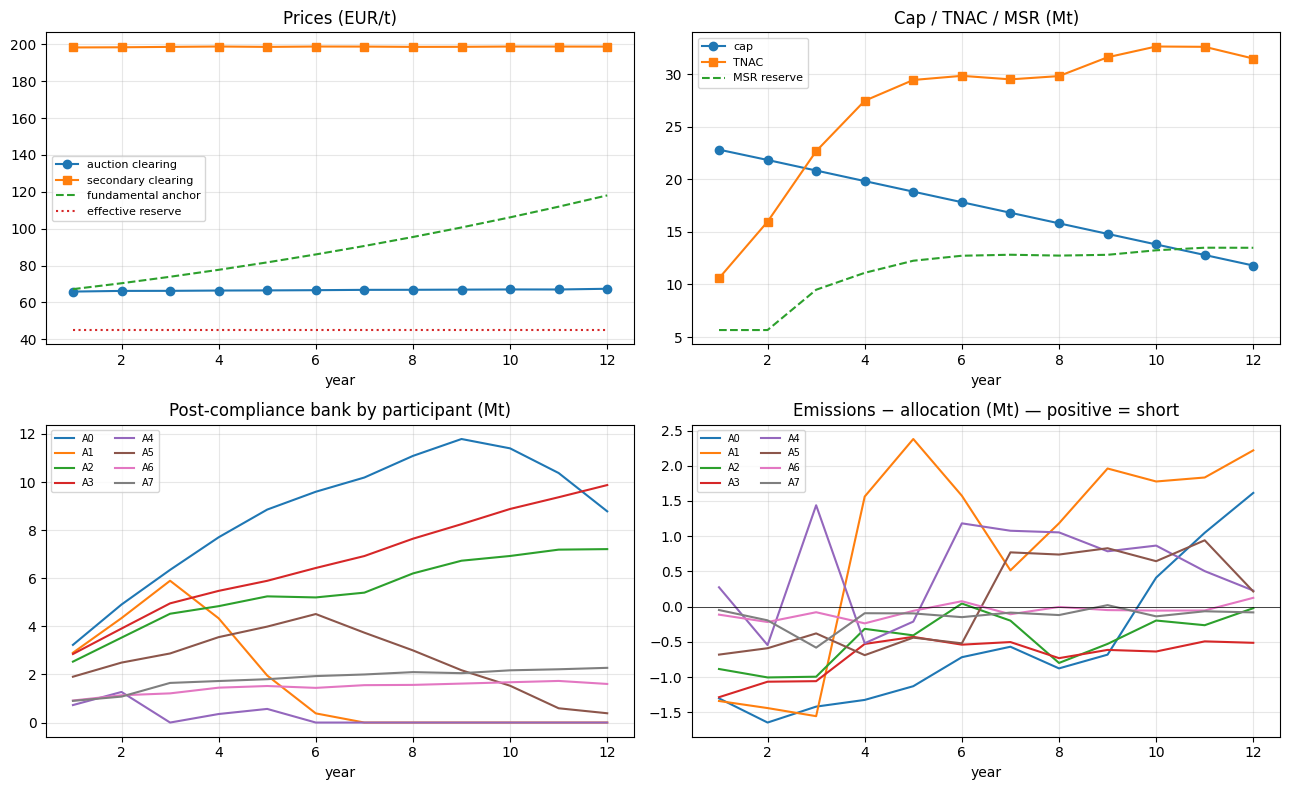

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
ax = axes[0, 0]
ax.plot(market_summary_df["year"], market_summary_df["auction_clearing_eur"], "-o", label="auction clearing")
ax.plot(market_summary_df["year"], market_summary_df["secondary_clearing_eur"], "-s", label="secondary clearing")
ax.plot(market_summary_df["year"], market_summary_df["anchor_eur"], "--", label="fundamental anchor")
ax.plot(market_summary_df["year"], market_summary_df["reserve_eur"], ":", label="effective reserve")
ax.set_title("Prices (EUR/t)"); ax.set_xlabel("year"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(market_summary_df["year"], market_summary_df["cap_mt"], "-o", label="cap")
ax.plot(market_summary_df["year"], market_summary_df["tnac_mt"], "-s", label="TNAC")
ax.plot(market_summary_df["year"], market_summary_df["msr_reserve_mt"], "--", label="MSR reserve")
ax.set_title("Cap / TNAC / MSR (Mt)"); ax.set_xlabel("year"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
for i in range(N_TOTAL):
    sub = per_company_df[per_company_df["agent"] == i]
    ax.plot(sub["year"], sub["bank_post_compliance"], label=participant_label(i))
ax.set_title("Post-compliance bank by participant (Mt)"); ax.set_xlabel("year")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

ax = axes[1, 1]
for i in range(N_TOTAL):
    sub = per_company_df[per_company_df["agent"] == i]
    ax.plot(sub["year"], sub["emissions_mt"] - sub["allocation_mt"], label=participant_label(i))
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Emissions − allocation (Mt) — positive = short")
ax.set_xlabel("year"); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 14. Optional CSV export

Set `EXPORT_CSV = True` at the top of the notebook to dump every dataframe above into `EXPORT_DIR/`. Filenames are tagged with `INSPECT_YEAR` and `INSPECT_AGENT` so multiple invocations can coexist.


In [15]:
if EXPORT_CSV:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    tag = f"y{INSPECT_YEAR:02d}_a{INSPECT_AGENT:02d}_seed{SEED}"
    market_summary_df.to_csv(EXPORT_DIR / f"market_summary_{tag}.csv", index=False)
    per_company_df.to_csv(EXPORT_DIR / f"per_company_yearly_{tag}.csv", index=False)
    bidding_df.to_csv(EXPORT_DIR / f"bidding_year{INSPECT_YEAR:02d}.csv", index=False)
    secondary_df.to_csv(EXPORT_DIR / f"secondary_year{INSPECT_YEAR:02d}.csv", index=False)
    compliance_df.to_csv(EXPORT_DIR / f"compliance_year{INSPECT_YEAR:02d}.csv", index=False)
    investment_df.to_csv(EXPORT_DIR / f"investment_year{INSPECT_YEAR:02d}.csv", index=False)
    budget_df.to_csv(EXPORT_DIR / f"budget_year{INSPECT_YEAR:02d}.csv", index=False)
    if not reward_channels_df.empty:
        reward_channels_df.to_csv(EXPORT_DIR / f"reward_channels_year{INSPECT_YEAR:02d}.csv", index=False)
    if not per_agent_diag_df.empty:
        per_agent_diag_df.to_csv(EXPORT_DIR / f"per_agent_diag_year{INSPECT_YEAR:02d}.csv", index=False)
    walk_df.to_csv(EXPORT_DIR / f"agent{INSPECT_AGENT:02d}_walkthrough.csv", index=False)
    mix_history_df.to_csv(EXPORT_DIR / f"agent{INSPECT_AGENT:02d}_mix_history.csv", index=False)
    print(f"Wrote CSV exports to {EXPORT_DIR}")
else:
    print("EXPORT_CSV is False — set it to True at the top of the notebook to dump CSVs.")


EXPORT_CSV is False — set it to True at the top of the notebook to dump CSVs.


## 15. Raw `year_log` access

Every dataframe above is derived from `year_logs[INSPECT_YEAR - 1]`. The raw dict is kept around for ad-hoc deep dives — print its keys here, and pull whatever else you need (e.g. `opponent_snapshots`, `terminal_*_values`, `rewards_base`, `rewards_shaping`, etc.).


In [16]:
print(f"year_log keys (year {INSPECT_YEAR}):")
display(pd.DataFrame({"key": sorted(year_log.keys())}))

# Example ad-hoc pull:
# rewards_base    = year_log["rewards_base"]
# rewards_shaping = year_log["rewards_shaping"]
# opponent_snap   = year_log["opponent_snapshots"]


year_log keys (year 12):


,key
0,_year_1based
1,allocations
2,anchor_t
3,auction_stats
4,auction_volume
...,...
81,treasury_drawn
82,treasury_reserves
83,unsold_rollover_in
84,unsold_rollover_out


## 16. v8.6.1 Per-year credit & compliance diagnostics

For the selected episode, surface the new year-level data points added in v8.6.1:

* Carry-forward debt at year start vs end (debt cascade).
* Coverage gap (`max(0, need − alloc)`) before secondary trading.
* Treasury balance and outstanding emergency loan.
* Auction concentration (HHI) and secondary-market liquidity counts.

The cell below reads from `episode_yr_df` — defensively no-ops when columns are missing (older logs).


In [17]:
# Section 16 — v8.6.1 expanded per-year diagnostics for the focal episode.
# Falls back gracefully to a brief notice when the underlying log predates 8.6.1.
import pandas as pd

try:
    _yr = episode_yr_df  # one row per year for the focal episode
except NameError:
    _yr = None

if _yr is None or len(_yr) == 0:
    print("[s16] episode_yr_df not available — run the rollout cells first.")
else:
    cols_present = set(_yr.columns)
    market_cols = [c for c in ["year", "auction_hhi", "auction_max_agent_share",
                               "auction_total_demand", "auction_unsold",
                               "auction_failed", "auction_defaults",
                               "secondary_n_buyers_executed",
                               "secondary_n_sellers_executed",
                               "common_emission_shock", "fundamental_anchor"]
                   if c in cols_present]
    if len(market_cols) > 1:
        print("Auction & secondary-market panel:")
        display(_yr[market_cols].round(3))
    else:
        print("[s16] Auction-internals columns missing — pre-8.6.1 log.")

    # Per-agent: carry-forward, coverage gap, effective penalty rate.
    rows = []
    for i in range(N_TOTAL):
        for y in range(len(_yr)):
            row = {"year": int(_yr.iloc[y]["year"]), "agent": i + 1}
            for stub in ["carry_forward_start", "carry_forward_end",
                         "coverage_gap", "effective_penalty_rate",
                         "treasury_reserve", "loan_outstanding"]:
                col = f"{stub}_A{i+1}"
                if col in cols_present:
                    row[stub] = float(_yr.iloc[y][col])
            rows.append(row)
    pa_df = pd.DataFrame(rows)
    if len(pa_df.columns) > 2:
        print("\nPer-agent compliance & credit state by year (focal episode):")
        display(pa_df.round(3))
    else:
        print("[s16] Per-agent v8.6.1 columns missing — pre-8.6.1 log.")


[s16] episode_yr_df not available — run the rollout cells first.
